In [34]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
%matplotlib notebook

In [186]:
heatmap1 = np.load('tracker2_array.npy')

<IPython.core.display.Javascript object>


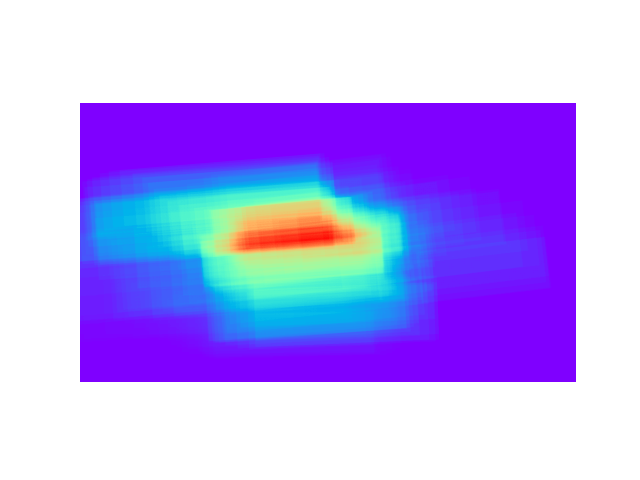

In [187]:
plt.figure()
plt.imshow(heatmap1, cmap='rainbow')
plt.axis('off')
plt.savefig('test.png', pad_inches=0)

In [201]:
# heatmap = heatmap1/80
heatmap = heatmap1/np.max(heatmap1)
# must convert to type unit8
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

<IPython.core.display.Javascript object>


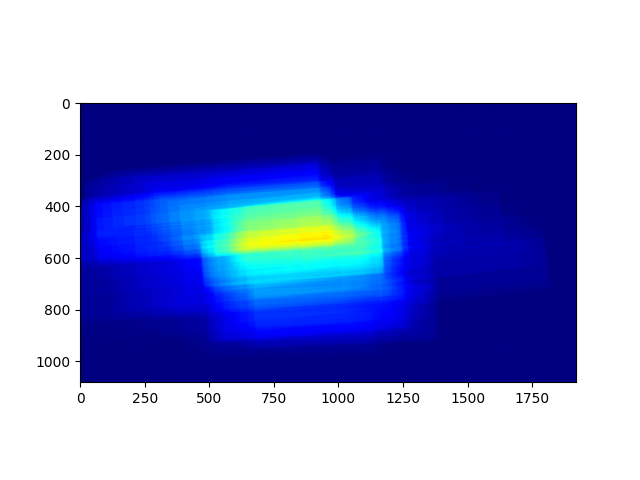

In [203]:
plt.figure()
plt.imshow(heatmap[:,:,::-1]/255)

In [204]:
np.max(heatmap1)

53.33476633878487

In [205]:
img = cv2.imread('test.jpg')

In [206]:
superimposed_img1 = heatmap*0.6+img*0.3

In [207]:
np.max(superimposed_img1)

229.5

<IPython.core.display.Javascript object>


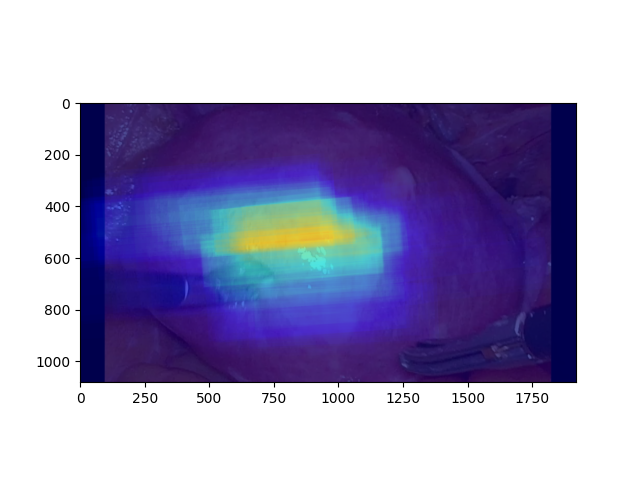

In [208]:
plt.figure()
plt.imshow(superimposed_img1[:,:,::-1]/255)

In [73]:
cv2.imwrite('imposed.jpg', superimposed_img1)

True

In [152]:
x, y = np.arange(450,500), np.arange(750,860)

In [153]:
x, y

(array([450, 451, 452, 453, 454, 455, 456, 457, 458, 459, 460, 461, 462,
        463, 464, 465, 466, 467, 468, 469, 470, 471, 472, 473, 474, 475,
        476, 477, 478, 479, 480, 481, 482, 483, 484, 485, 486, 487, 488,
        489, 490, 491, 492, 493, 494, 495, 496, 497, 498, 499]),
 array([750, 751, 752, 753, 754, 755, 756, 757, 758, 759, 760, 761, 762,
        763, 764, 765, 766, 767, 768, 769, 770, 771, 772, 773, 774, 775,
        776, 777, 778, 779, 780, 781, 782, 783, 784, 785, 786, 787, 788,
        789, 790, 791, 792, 793, 794, 795, 796, 797, 798, 799, 800, 801,
        802, 803, 804, 805, 806, 807, 808, 809, 810, 811, 812, 813, 814,
        815, 816, 817, 818, 819, 820, 821, 822, 823, 824, 825, 826, 827,
        828, 829, 830, 831, 832, 833, 834, 835, 836, 837, 838, 839, 840,
        841, 842, 843, 844, 845, 846, 847, 848, 849, 850, 851, 852, 853,
        854, 855, 856, 857, 858, 859]))

In [176]:
x_,y_ = np.meshgrid(x,y)

In [177]:
x_.ravel(),y_.ravel()

(array([450, 451, 452, ..., 497, 498, 499]),
 array([750, 750, 750, ..., 859, 859, 859]))

In [209]:
theta = -1/6 * np.pi
x_mid = (450+500)/2
y_mid = (750+860)/2
x_rot = np.cos(theta) * (x_.ravel() - x_mid) - np.sin(theta) * (y_.ravel() - y_mid) + x_mid
x_rot = np.clip(x_rot, 0 ,1919)
y_rot = np.sin(theta) * (x_.ravel() - x_mid) + np.cos(theta) * (y_.ravel() - y_mid) + y_mid
y_rot = np.clip(y_rot, 0 ,1079)

In [210]:
np.where(img==0), x_rot.astype(np.int)

/tmp/ipykernel_27970/2615712503.py:1: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  np.where(img==0), x_rot.astype(np.int)


((array([   0,    0,    0, ..., 1079, 1079, 1079]),
  array([   0,    0,    0, ..., 1919, 1919, 1919]),
  array([0, 1, 2, ..., 0, 1, 2])),
 array([425, 426, 427, ..., 521, 521, 522]))

In [211]:
img_test = img.copy()
img_test[y_.ravel(), x_.ravel()] = 0
img_rot_test = img.copy()
img_rot_test[y_rot.astype(np.int), x_rot.astype(np.int)] = 0

/tmp/ipykernel_27970/1688507135.py:4: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  img_rot_test[y_rot.astype(np.int), x_rot.astype(np.int)] = 0


<IPython.core.display.Javascript object>


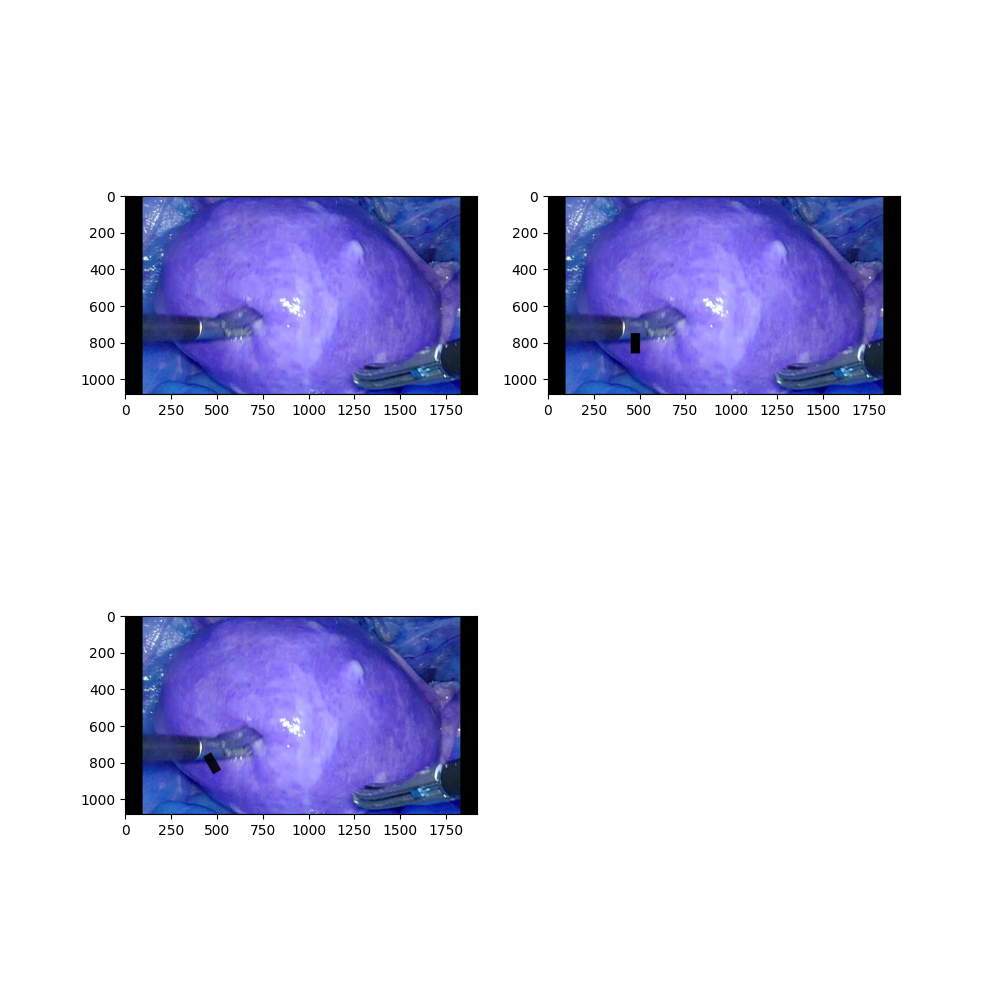

In [212]:
plt.figure(figsize=(10,10))
plt.subplot(221)
plt.imshow(img)
plt.subplot(222)
plt.imshow(img_test)
plt.subplot(223)
plt.imshow(img_rot_test)

In [257]:
black = np.zeros((1080,1920))

In [258]:
bbox = np.array([[     246.67],
       [     471.07],
       [     924.79],
       [     587.55],
       [   -0.37386]])

In [259]:
y, x = np.arange(int(bbox[1]), int(bbox[3])), np.arange(int(bbox[0]), int(bbox[2]))
x_, y_ = np.meshgrid(x, y)
y_mid, x_mid = (bbox[1] + bbox[3]) / 2, (bbox[0] + bbox[2]) / 2
x_rot = np.cos(-bbox[-1]) * (x_.ravel() - x_mid) - np.sin(-bbox[-1]) * (y_.ravel() - y_mid) + x_mid
x_rot = np.clip(x_rot, 0, 1919)
y_rot = np.sin(-bbox[-1]) * (x_.ravel() - x_mid) + np.cos(-bbox[-1]) * (y_.ravel() - y_mid) + y_mid
y_rot = np.clip(y_rot, 0, 1079)
black[y_rot.astype(np.int), x_rot.astype(np.int)] = 1

/tmp/ipykernel_27970/3966466699.py:8: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  black[y_rot.astype(np.int), x_rot.astype(np.int)] = 1


In [260]:
x_, x_rot

(array([[246, 247, 248, ..., 921, 922, 923],
        [246, 247, 248, ..., 921, 922, 923],
        [246, 247, 248, ..., 921, 922, 923],
        ...,
        [246, 247, 248, ..., 921, 922, 923],
        [246, 247, 248, ..., 921, 922, 923],
        [246, 247, 248, ..., 921, 922, 923]]),
 array([290.76247986, 291.69340443, 292.624329  , ..., 877.13723922,
        878.06816378, 878.99908835]))

<IPython.core.display.Javascript object>


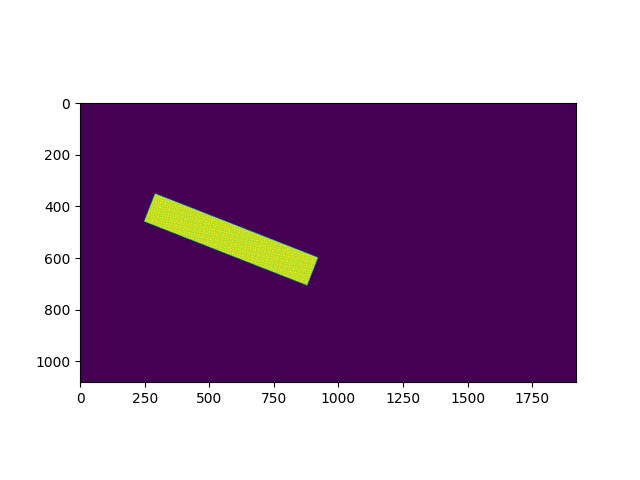

In [261]:
plt.figure()
plt.imshow(black)